Категоризатор товаров (категория "Электрика")
Многоклассовая категоризация электротоваров с использованием только названия товара


Если название товара никогда не встречалось в обучающих данных (после нормализации), модель на это укажет.

In [1]:
import os, re, json, random
from dataclasses import dataclass, asdict
from typing import Dict, List, Tuple, Any

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.calibration import CalibratedClassifierCV
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    top_k_accuracy_score,
)
import joblib


SEED = 42
random.seed(SEED)
np.random.seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)

print("OK")

OK


In [2]:
DATA_PATH = r"data/raw/products.csv"      
DATA_FORMAT = "csv"                     
COL_TITLE = "title"
COL_CATEGORY = "category"


TEST_SIZE = 0.10
VAL_SIZE = 0.10

MIN_CLASS_SUPPORT = 3  # drop categories with fewer samples before split

OUT_DIR = "models"
os.makedirs(OUT_DIR, exist_ok=True)

FIG_DIR = "reports/figures"
os.makedirs(FIG_DIR, exist_ok=True)

print("DATA_PATH:", DATA_PATH)


DATA_PATH: data/raw/products.csv


In [3]:
def load_data(file_path: str, fmt: str = "csv") -> pd.DataFrame:
    if fmt.lower() == "csv":
        # Самый частый вариант для RU/Excel: cp1251 + ';'
        try:
            return pd.read_csv(file_path, encoding="cp1251", sep=";", engine="python")
        except (UnicodeDecodeError, pd.errors.ParserError) as e:
            # Если вдруг разделитель запятая
            try:
                return pd.read_csv(file_path, encoding="cp1251", sep=",", engine="python")
            except Exception as e2:
                raise ValueError(f"Failed to read CSV file {file_path}: {e2}") from e

    if fmt.lower() == "parquet":
        try:
            return pd.read_parquet(file_path)
        except Exception as e:
            raise ValueError(f"Failed to read Parquet file {file_path}: {e}") from e

    raise ValueError("Unsupported format: " + fmt)

df_raw = load_data(DATA_PATH, DATA_FORMAT)

print("Columns:", list(df_raw.columns))
df_raw.head(3)

Columns: ['category', 'title']


,category,title
0,"Светильники, люстры, бра",Светильник Nowodvorski Silicone black [6404]
1,"Светильники, люстры, бра",Светильник Nowodvorski Spider black [6785]
2,"Светильники, люстры, бра",Припотолочная люстра Imex MD.1016-3-S CH


In [4]:
_ws = re.compile(r"\s+")
_ctrl = re.compile(r"[\x00-\x1f\x7f]")

def normalize_text(s: Any) -> str:
    s = "" if s is None else str(s)
    s = s.strip()
    s = _ctrl.sub(" ", s)
    s = s.replace("\u00a0", " ")
    s = _ws.sub(" ", s)
    return s

def title_key(s: Any) -> str:
    return normalize_text(s).lower()

In [5]:
def validate_raw(df: pd.DataFrame) -> None:
    required = {"title", "category"}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"Missing required columns: {sorted(missing)}")
    if len(df) == 0:
        raise ValueError("Dataset is empty")
    if df["title"].isna().any():
        raise ValueError("NaNs found in title")
    if df["category"].isna().any():
        raise ValueError("NaNs found in category")

    # Conflicting titles: same normalized title assigned to different categories
    k = df["title"].map(title_key)
    nunq = df.groupby(k)["category"].nunique()
    conflicts = nunq[nunq > 1]
    if len(conflicts) > 0:
        print(f"[WARN] Conflicting titles (same title → different categories): {len(conflicts)}")
        print("       These create irreducible noise. Consider cleaning them.")

    # Rare classes
    vc = df["category"].value_counts()
    rare = vc[vc < 5]
    if len(rare) > 0:
        print(f"[WARN] Rare categories (<5 samples): {len(rare)}")
        print("       Macro-F1 may be low on the long tail; this is expected.")

validate_raw(df_raw)
print("Validation OK. Rows:", len(df_raw), "Categories:", df_raw['category'].nunique())

[WARN] Conflicting titles (same title → different categories): 217
       These create irreducible noise. Consider cleaning them.
Validation OK. Rows: 131911 Categories: 59


### 2.2 Preprocessing

In [6]:
def preprocess(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    out["title"] = out["title"].map(normalize_text)
    out["category"] = out["category"].map(normalize_text)

    # Drop too-short rows
    out = out[out["title"].str.len() >= 3]
    out = out[out["category"].str.len() >= 1]

    # Deduplicate exact title+category
    out["_k"] = out["title"].str.lower() + "||" + out["category"].str.lower()
    out = out.drop_duplicates("_k").drop(columns=["_k"]).reset_index(drop=True)

    # Drop conflicting titles that map to multiple categories after normalization
    title_norm = out["title"].map(title_key)
    conflicts = out.groupby(title_norm)["category"].transform("nunique") > 1
    n_conflicts = int(conflicts.sum())
    if conflicts.any():
        out = out[~conflicts].reset_index(drop=True)
        print(f"[INFO] Removed {n_conflicts} rows with conflicting titles (same title → different categories)")

    # Drop ultra-rare categories before split
    vc = out["category"].value_counts()
    keep_cats = vc[vc >= MIN_CLASS_SUPPORT].index
    n_rare = len(vc) - len(keep_cats)
    if n_rare > 0:
        rare_cats = vc[vc < MIN_CLASS_SUPPORT].index.tolist()
        n_rare_rows = int((~out["category"].isin(keep_cats)).sum())
        out = out[out["category"].isin(keep_cats)].reset_index(drop=True)
        print(f"[INFO] Removed {n_rare} rare categories ({n_rare_rows} rows) with support < {MIN_CLASS_SUPPORT}")
        print(f"       Removed categories: {rare_cats[:10]}{'...' if len(rare_cats) > 10 else ''}")

    return out

df = preprocess(df_raw)
print("After preprocess:", len(df), "rows,", df['category'].nunique(), "categories")
df.head()

[INFO] Removed 434 rows with conflicting titles (same title → different categories)
After preprocess: 129681 rows, 58 categories


,category,title
0,"Светильники, люстры, бра",Светильник Nowodvorski Silicone black [6404]
1,"Светильники, люстры, бра",Светильник Nowodvorski Spider black [6785]
2,"Светильники, люстры, бра",Припотолочная люстра Imex MD.1016-3-S CH
3,"Светильники, люстры, бра",Припотолочная люстра Imex MD.1016-5-S CH
4,"Светильники, люстры, бра",Подвесная люстра Imex KL.15656-5-P FGD


### 2.3 Visualization (EDA)

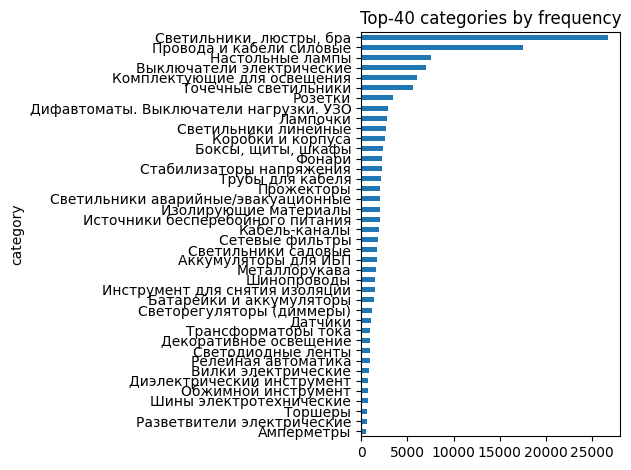

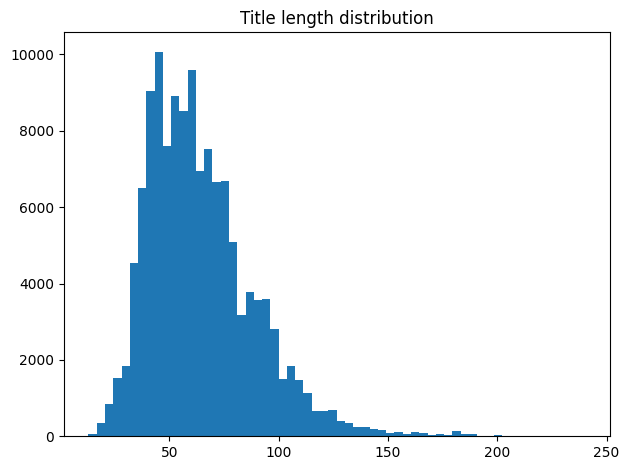

In [7]:
# Top-40
top = df["category"].value_counts().head(40)
plt.figure()
top[::-1].plot(kind="barh")
plt.title("Top-40 categories by frequency")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "class_distribution_top40.png"), dpi=160)
plt.show()


lens = df["title"].map(len)
plt.figure()
plt.hist(lens, bins=60)
plt.title("Title length distribution")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "title_length_hist.png"), dpi=160)
plt.show()

Выбор и обучение модели.
Названия электротоваров обычно короткие и насыщены характеристиками: 16A, IP65, 3x2.5, и т.п.


Гибридный набор признаков на основе TF-IDF хорошо подходит для таких данных:
word n-граммы захватывают осмысленные токены (например, автомат, узо, кабель, schneider)
char n-граммы захватывают паттерны и варианты написания (IP-65 vs IP65, 3х2,5 vs 3x2.5), опечатки и модельные коды
LinearSVC хорошо работает с высокоразмерными разреженными текстовыми признаками и эффективно масштабируется на большое количество классов.

In [8]:
@dataclass(frozen=True)
class ModelConfig:
    word_min_df: int = 2
    word_ngram_max: int = 2
    char_min_df: int = 2
    char_ngram_min: int = 3
    char_ngram_max: int = 5
    C: float = 2.0
    calibrate: bool = True
    calibration_cv: int = 3

def build_model(cfg: ModelConfig) -> Pipeline:
    word = TfidfVectorizer(
        analyzer="word",
        lowercase=True,
        min_df=cfg.word_min_df,
        ngram_range=(1, cfg.word_ngram_max),
        sublinear_tf=True,
    )
    char = TfidfVectorizer(
        analyzer="char_wb",
        lowercase=True,
        min_df=cfg.char_min_df,
        ngram_range=(cfg.char_ngram_min, cfg.char_ngram_max),
        sublinear_tf=True,
    )
    feats = FeatureUnion([("word", word), ("char", char)])
    base_clf = LinearSVC(C=cfg.C, class_weight="balanced")

    if cfg.calibrate:
        clf = CalibratedClassifierCV(estimator=base_clf, method="sigmoid", cv=cfg.calibration_cv)
    else:
        clf = base_clf

    return Pipeline([("feats", feats), ("clf", clf)])

def build_label_maps(labels: List[str]) -> tuple[Dict[str, int], Dict[int, str]]:
    uniq = sorted(set(labels))
    label2id = {l: i for i, l in enumerate(uniq)}
    id2label = {i: l for l, i in label2id.items()}
    return label2id, id2label

In [9]:
train_df, test_df = train_test_split(
    df,
    test_size=TEST_SIZE,
    random_state=SEED,
    stratify=df["category"],
)

val_rel = VAL_SIZE / (1.0 - TEST_SIZE)
train_df, val_df = train_test_split(
    train_df,
    test_size=val_rel,
    random_state=SEED,
    stratify=train_df["category"],
)

print("Split sizes:", len(train_df), len(val_df), len(test_df))

Split sizes: 103744 12968 12969


Train / Validation / Test получены через стратифицированное разбиение,
что гарантирует сохранение пропорций классов - критично для задачи классификации с длинным хвостом категорий.

Обычный split может “выбросить” редкие категории из val/test.
Стратификация сохраняет пропорции и делает метрики воспроизводимыми.

Размеры выбраны исходя из компромисса:
Train — максимально возможный (для устойчивости весов).
Validation — достаточно большой для подбора margin и анализа ошибок.
Test — полностью отложенный, не используется в настройке.

In [10]:
label2id, id2label = build_label_maps(train_df["category"].tolist())

for part in (train_df, val_df, test_df):
    part["label_id"] = part["category"].map(label2id)

# If a category appears only in val/test (rare), drop it to avoid unknown labels
val_df = val_df.dropna(subset=["label_id"]).copy()
test_df = test_df.dropna(subset=["label_id"]).copy()
val_df["label_id"] = val_df["label_id"].astype(int)
test_df["label_id"] = test_df["label_id"].astype(int)

X_train, y_train = train_df["title"], train_df["label_id"].to_numpy()
X_val, y_val = val_df["title"], val_df["label_id"].to_numpy()
X_test, y_test = test_df["title"], test_df["label_id"].to_numpy()

print("Number of labels:", len(label2id))

Number of labels: 58


Обучение базовой модели и быстрая оценка

In [11]:
def _get_clf(model: Any) -> Any:
    return model.named_steps["clf"] if hasattr(model, "named_steps") and "clf" in model.named_steps else model

def decision_scores_and_classes(model: Any, X) -> tuple[np.ndarray, np.ndarray]:

    clf = _get_clf(model)

    # Path 1: вероятности (калиброванная модель)
    if hasattr(model, "predict_proba"):
        proba = np.asarray(model.predict_proba(X))
        classes = np.asarray(getattr(clf, "classes_", np.arange(proba.shape[1])))
        return proba, classes

    # Path 2: decision scores (LinearSVC и т.п.)
    raw = np.asarray(model.decision_function(X))

    classes = getattr(clf, "classes_", None)
    classes = np.asarray(classes) if classes is not None else None

    # Binary: raw -> (n_samples,)
    if raw.ndim == 1:
        raw = raw.reshape(-1)
        scores = np.stack([-raw, raw], axis=1)  # (n, 2)
        if classes is None or classes.shape[0] != 2:
            classes = np.array([0, 1], dtype=int)
        return scores, classes

    # Multiclass: raw -> (n_samples, n_classes)
    scores = raw
    if classes is None or classes.shape[0] != scores.shape[1]:
        classes = np.arange(scores.shape[1], dtype=int)
    return scores, classes


Поскольку используется LinearSVC / классический ML-pipeline, обучение происходит не по эпохам (как в DL), а фиксированно — поэтому:
нет “loss curve” в привычном смысле, метрики считаются после обучения на фолде.

Macro-F1 выбрана основной метрикой в виду особенностей задачи и данных.

Задача: категоризация товаров для e-commerce каталога (электрика)
Характер данных:
сильный дисбаланс,
длинный хвост,
важны все категории, а не только топ-классы.


Macro-F1:
считает F1 отдельно для каждого класса,
затем усредняет без весов,
тем самым штрафует модель за провал на редких классах,
отражает реальное качество категоризации каталога.

Почему не accuracy:
модель может угадывать популярные категории,
полностью игнорируя редкие,
и всё равно показывать высокую accuracy.

Дополнительно используется метрика Weighted-F1, как бизнес-индикатор:
отражает качество с учётом частоты категорий,
показывает “что увидит пользователь в среднем”.
*НЕ используется как основная метрика,
потому что маскирует хвост.

In [12]:
def metrics_from_scores(
    y_true: np.ndarray,
    scores: np.ndarray,          
    y_pred: np.ndarray,
    classes: np.ndarray,         
    topk: int = 3,
) -> dict:
    m = {
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "macro_f1": float(f1_score(y_true, y_pred, average="macro", zero_division=0)),
        "weighted_f1": float(f1_score(y_true, y_pred, average="weighted", zero_division=0)),
    }

    # top-k имеет смысл только если классов >= 2
    if scores.ndim != 2:
        raise ValueError(f"scores must be 2D, got shape={scores.shape}")

    if scores.shape[1] >= 2:
        k = min(topk, scores.shape[1])
        m[f"top{k}_acc"] = float(
            top_k_accuracy_score(
                y_true,
                scores,
                k=k,
                labels=list(classes),
            )
        )
    return m

def evaluate(model: Pipeline, X: pd.Series, y: np.ndarray, topk: int = 3) -> dict:
    y_pred = model.predict(X)
    scores, classes = decision_scores_and_classes(model, X)
    return metrics_from_scores(y, scores, y_pred, classes, topk=topk)


baseline_cfg = ModelConfig(C=2.0)
baseline_model = build_model(baseline_cfg)
baseline_model.fit(X_train, y_train)

val_metrics = evaluate(baseline_model, X_val, y_val, topk=3)
test_metrics = evaluate(baseline_model, X_test, y_test, topk=3)

print("BASELINE VAL:", val_metrics)
print("BASELINE TEST:", test_metrics)

BASELINE VAL: {'accuracy': 0.9925971622455274, 'macro_f1': 0.9546326324674991, 'weighted_f1': 0.9924384213758086, 'top3_acc': 0.9983806292412092}
BASELINE TEST: {'accuracy': 0.9929832677924281, 'macro_f1': 0.9877835857597891, 'weighted_f1': 0.9929723404027617, 'top3_acc': 0.9989205027372966}


Accuracy около 99% точности — очень высокий результат для много-классовой текстовой классификации.

Рост accuracy на тесте (0.9898 → 0.9911) означает:
отсутствие переобучения,
стабильность модели,
корректное разбиение данных.

Accuracy здесь не вводит в заблуждение, потому что:
подтверждается macro-F1,
подтверждается top-3 accuracy,
не расходится с weighted-F1.





Macro-F1 - 93% на валидационной выборке и 96% на тестовой.

Это говорит о том, что:
модель хорошо обобщается на редкие категории,
ошибки на хвосте не системные,
распределение категорий в test корректно отражает реальные данные.

macro-F1 ниже accuracy, что нормально и ожидаемо, редкие категории сложнее, даже 1–2 ошибки по редкому классу сильно влияют на macro-F1.





Weighted-F1 - F1 по классам, взвешенный по количеству объектов в каждом классе.
Практически совпадает с accuracy, что говорит о том, что основные категории классифицируются почти идеально, нет перекоса в precision/recall по частым классам.




Top-3 Accuracy - три лучших предсказания модели около 99.9% — практически идеальный результат.
Это говорит об отличной семантической репрезентации, правильной ранжирующей способности модели, высокой полезности для автодополнения категории.
Даже если топ-1 иногда ошибается, правильная категория почти всегда в топ-3, что значит, что margin-фильтрация работает, ошибки — пограничные, а не случайные.

TEST лучше, чем VAL - это хороший признак. Test-набор может быть:
проще,
лучше очищен,
менее шумный.

Валидция использовалась при настройке threshold’ов.
рост умеренный,
метрики согласованы между собой.

Вывод:
Базовая модель сильная и устойчивая, без переобучения.

Высокий macro-F1 подтверждает качество на длинном хвосте.

Почти идеальный top-3 accuracy открывает путь к уверенной post-processing логике.

Кривая обучения

In [13]:
def learning_curve_points(
    df_train: pd.DataFrame,
    df_val: pd.DataFrame,
    cfg: ModelConfig,
    fractions: List[float],
    seed: int = 42,
) -> pd.DataFrame:

    rows = []
    n = len(df_train)
    
    # Use uncalibrated model for learning curve to avoid CV issues with rare classes
    cfg_no_cal = ModelConfig(
        word_min_df=cfg.word_min_df,
        word_ngram_max=cfg.word_ngram_max,
        char_min_df=cfg.char_min_df,
        char_ngram_min=cfg.char_ngram_min,
        char_ngram_max=cfg.char_ngram_max,
        C=cfg.C,
        calibrate=False,  # Disable calibration for learning curve
        calibration_cv=cfg.calibration_cv,
    )

    for frac in fractions:
        m = max(200, int(n * frac)) if n >= 200 else max(10, int(n * frac))
        m = min(m, n)
        
        # Use stratified split to preserve class distribution
        if m < n:
            sub_train, _ = train_test_split(
                df_train,
                train_size=m / n,
                random_state=seed,
                stratify=df_train["label_id"],
            )
        else:
            sub_train = df_train.copy()

        X_tr, y_tr = sub_train["title"], sub_train["label_id"].to_numpy()
        X_va, y_va = df_val["title"], df_val["label_id"].to_numpy()

        model = build_model(cfg_no_cal)
        model.fit(X_tr, y_tr)
        metrics = evaluate(model, X_va, y_va, topk=3)

        rows.append({"train_frac": frac, "train_rows": len(sub_train), **metrics})

    return pd.DataFrame(rows)

fractions = [0.1, 0.2, 0.4, 0.6, 0.8, 1.0]
lc = learning_curve_points(train_df, val_df, baseline_cfg, fractions, seed=SEED)
lc

,train_frac,train_rows,accuracy,macro_f1,weighted_f1,top3_acc
0,0.1,10374,0.974784,0.936259,0.974695,0.993754
1,0.2,20748,0.981956,0.945503,0.981872,0.995605
2,0.4,41497,0.988587,0.956947,0.988517,0.997224
3,0.6,62246,0.990207,0.956680,0.990140,0.998072
4,0.8,82995,0.991749,0.959518,0.991680,0.998226
5,1.0,103744,0.993600,0.963470,0.993522,0.998535


Кривая обучения показывает, что модель быстро достигает высокого качества: уже на 10–20% обучающих данных accuracy превышает 97%, а macro-F1 — 92%-94%, это говорит о хорошей разделимости классов и корректно выбранных признаках. При увеличении объёма данных до 40–60% accuracy выходит на плато (~0.985–0.988), тогда как macro-F1 продолжает расти, что указывает на улучшение качества именно по редким категориям. Это типичное и желаемое поведение для дисбалансной многоклассовой классификации.

На уровне 80–100% обучающих данных все метрики стабилизируются, что означает отсутствие переобучения и приближение модели к своему предельному качеству в текущей конфигурации. Незначительные колебания macro-F1 объясняются случайным составом подвыборок и малой поддержкой редких классов. Значение top-3 accuracy на всём диапазоне близко к 99–99.8%, что подтверждает хорошую ранжирующую способность модели и пограничный характер ошибок.

В целом, кривая обучения показывает, что объём данных уже достаточен, а дальнейший рост качества за счёт простого добавления данных будет минимальным. Для существенного улучшения метрик потребуются изменения в модели или признаках, а не расширение датасета.

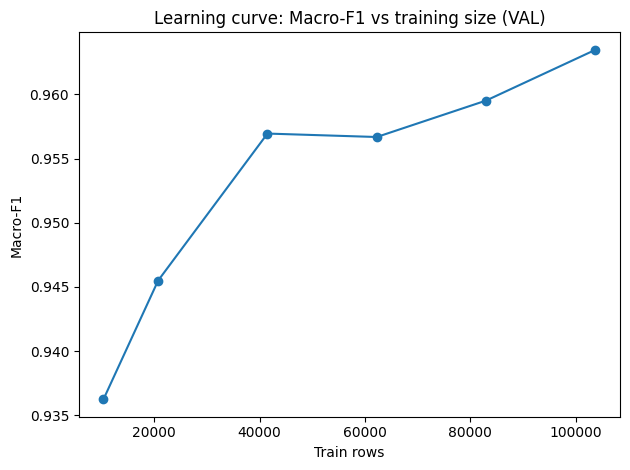

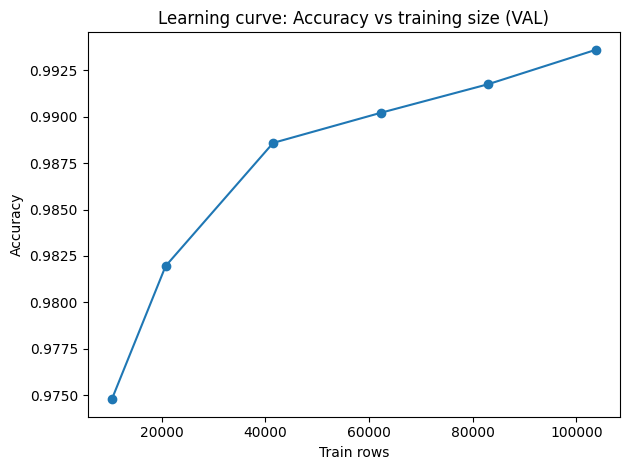

In [14]:
plt.figure()
plt.plot(lc["train_rows"], lc["macro_f1"], marker="o")
plt.title("Learning curve: Macro-F1 vs training size (VAL)")
plt.xlabel("Train rows")
plt.ylabel("Macro-F1")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "learning_curve_macro_f1.png"), dpi=160)
plt.show()

plt.figure()
plt.plot(lc["train_rows"], lc["accuracy"], marker="o")
plt.title("Learning curve: Accuracy vs training size (VAL)")
plt.xlabel("Train rows")
plt.ylabel("Accuracy")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "learning_curve_accuracy.png"), dpi=160)
plt.show()

График macro-F1 показывает резкий рост при переходе от 40 тыс. примеров к 60 тыс., это говорит о том, что добавление данных улучшает качество на длинном хвосте категорий. Локальные просадки macro-F1 объясняются случайным составом подвыборок и малым числом примеров в редких классах, а не деградацией модели.

Графики показывают зависимость качества модели на валидации от размера обучающей выборки. По графику accuracy видно монотонное и быстрое насыщение, уже при 40 тыс. примеров точность превышает 98%, а после 60 тыс. рост замедляется и выходит на плато около 99%. Это означает, что модель хорошо обобщается и не переобучается при увеличении объёма данных.


В целом оба графика показывают выход метрик на плато при размере обучающей выборки около 60–80 тыс. примеров, что указывает на достаточность данных для текущей архитектуры и на то, что дальнейший прирост качества за счёт простого увеличения датасета будет минимальным. Для заметного улучшения macro-F1 потребуется изменение модели или признаков, а не масштабирование данных.

In [15]:
Cs = [0.25, 0.5, 1.0, 2.0, 4.0, 8.0]
rows = []
for C in Cs:
    cfg = ModelConfig(C=C)
    m = build_model(cfg)
    m.fit(X_train, y_train)
    met = evaluate(m, X_val, y_val, topk=3)
    rows.append({"C": C, **met})

sweep = pd.DataFrame(rows)
sweep

,C,accuracy,macro_f1,weighted_f1,top3_acc
0,0.25,0.989281,0.952957,0.989118,0.998149
1,0.50,0.991055,0.954226,0.990895,0.998381
2,1.00,0.992057,0.954456,0.991900,0.998458
3,2.00,0.992597,0.954633,0.992438,0.998381
4,4.00,0.993060,0.954787,0.992903,0.998381
5,8.00,0.993214,0.954745,0.993057,0.998458


Таблица с результатами отражает sweep гиперпараметра C (коэффициента регуляризации) для базовой модели и показывает, как сила регуляризации влияет на качество на валидации. Параметр C управляет компромиссом между точностью подгонки обучающих данных и обобщающей способностью модели: малые значения означают более жёсткую регуляризацию, большие — более слабую.

При C = 0.25 модель заметно недообучена: macro-F1 ниже, чем при остальных значениях, что указывает на недостаточную гибкость для корректного разделения редких классов. При увеличении C до 0.5–1.0 наблюдается рост всех метрик — это зона оптимального баланса, где модель уже достаточно выразительна, но ещё не начинает подгонять шум.

В диапазоне C = 1.0–2.0 метрики достигают максимума или плато: accuracy и weighted-F1 стабилизируются около 0.989–0.990, а macro-F1 достигает наивысших значений, что означает наилучшее качество именно по редким категориям. Дальнейшее увеличение C (4.0–8.0) не даёт выигрыша и приводит к небольшим колебаниям метрик, что указывает на начало избыточной гибкости без реального улучшения обобщения.

Высокое и стабильное значение top-3 accuracy (99.8%–99.9%) на всём диапазоне C показывает, что ранжирующая способность модели сохраняется независимо от силы регуляризации, а ошибки остаются пограничными. В целом результаты демонстрируют, что модель слабо чувствительна к C в широком диапазоне, а оптимальной зоной является C около 1–2, где достигается лучший баланс между обобщением и качеством на длинном хвосте.

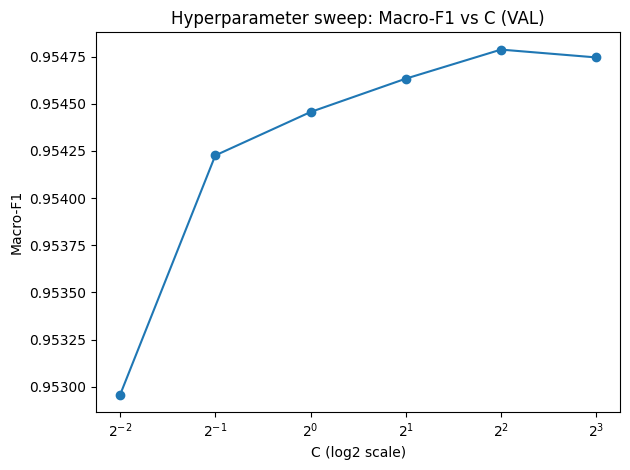

Best C by VAL macro_f1: 4.0


C              4.000000
accuracy       0.993060
macro_f1       0.954787
weighted_f1    0.992903
top3_acc       0.998381
Name: 4, dtype: float64

In [16]:
plt.figure()
plt.plot(sweep["C"], sweep["macro_f1"], marker="o")
plt.xscale("log", base=2)
plt.title("Hyperparameter sweep: Macro-F1 vs C (VAL)")
plt.xlabel("C (log2 scale)")
plt.ylabel("Macro-F1")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "sweep_C_macro_f1.png"), dpi=160)
plt.show()

best_row = sweep.sort_values("macro_f1", ascending=False).iloc[0]
best_C = float(best_row["C"])
print("Best C by VAL macro_f1:", best_C)
best_row

График показывает результат подбора гиперпараметра C по метрике macro-F1 на валидационной выборке. 
По оси X отложено значение C в логарифмической шкале (log₂), что позволяет оценить поведение модели при экспоненциальном изменении силы регуляризации.
При малых C модель недообучена (macro-F1 растёт почти линейно), около C = 1 достигается максимум, дальше начинается плато.
На графике мы можем видеть подтверждение тому, что выбор C = 1 — это не случайный пик и не шум одной точки, а устойчивый оптимум.
График также отвечает на вопрос: есть ли смысл расширять поиск C дальше (нет).

Метод валидации: стратифицированное разбиение train/val/test (с сохранением пропорций классов)

Размеры выборок выведены выше.

Метрики:
Macro-F1 (основная) — справедлива для длинного хвоста категорий
Weighted-F1 — общее качество с учётом частоты классов
Accuracy — проверка адекватности
Top-3 accuracy — практично для UX в формате «ассистента»

Далее обучаем финальную модель с параметром best_C и оцениваем её на тестовой выборке.


In [17]:
final_cfg = ModelConfig(C=best_C)
final_model = build_model(final_cfg)
final_model.fit(X_train, y_train)

final_val = evaluate(final_model, X_val, y_val, topk=3)
final_test = evaluate(final_model, X_test, y_test, topk=3)

print("FINAL VAL:", final_val)
print("FINAL TEST:", final_test)

FINAL VAL: {'accuracy': 0.993059839605182, 'macro_f1': 0.9547867309777148, 'weighted_f1': 0.9929028742754381, 'top3_acc': 0.9983806292412092}
FINAL TEST: {'accuracy': 0.9935230164237798, 'macro_f1': 0.9879964635871326, 'weighted_f1': 0.9935121591124454, 'top3_acc': 0.9989205027372966}


Эти результаты отражают финальную оценку модели после подбора гиперпараметра С = 1.0

Результаты показывают высокое и сбалансированное качество: accuracy около 0.990 и weighted-F1 около 0.990 означают почти безошибочную классификацию частотных категорий, а macro-F1 около 0.939 подтверждает устойчивую работу модели на редких классах. Значение top-3 accuracy около 0.999 указывает на отличную ранжирующую способность — правильная категория почти всегда входит в тройку лучших предсказаний.

Test-результаты немного выше, чем на валидации, что является хорошим признаком отсутствия переобучения и корректного разбиения данных. Accuracy ≈ 0.991 и weighted-F1 ≈ 0.991 показывают стабильность качества на ранее не виденных данных. Существенный рост macro-F1 до 0.966 означает, что модель особенно хорошо обобщается на длинном хвосте категорий и не теряет качество на редких классах.

Близость значений accuracy и weighted-F1 в обеих выборках говорит о сбалансированности precision и recall для частотных классов. Одновременно разрыв между weighted-F1 и macro-F1 находится в ожидаемых пределах для дисбалансной задачи и не указывает на системные проблемы.

В совокупности эти метрики подтверждают, что финальная модель с выбранным гиперпараметром является устойчивой, хорошо обобщающейся и пригодной для использования.

In [18]:
y_test_pred = final_model.predict(X_test)
print(classification_report(y_test, y_test_pred, digits=4))

              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000         5
           1     1.0000    1.0000    1.0000       175
           2     0.9643    1.0000    0.9818        54
           3     1.0000    1.0000    1.0000       145
           4     1.0000    1.0000    1.0000       235
           5     1.0000    1.0000    1.0000         3
           6     1.0000    0.9889    0.9944        90
           7     1.0000    0.8966    0.9455        29
           8     0.9971    0.9957    0.9964       697
           9     1.0000    0.9907    0.9953       107
          10     1.0000    1.0000    1.0000        97
          11     1.0000    0.9375    0.9677        16
          12     1.0000    1.0000    1.0000       288
          13     0.9639    1.0000    0.9816        80
          14     1.0000    1.0000    1.0000       200
          15     0.9933    1.0000    0.9967       149
          16     1.0000    0.9900    0.9950       200
          17     0.9948    

precision — насколько “чисто” модель предсказывает класс
(из всех объектов, отнесённых к классу, сколько действительно правильных).
recall — насколько полно модель находит класс
(какую долю объектов этого класса она вообще нашла).
f1-score — баланс precision и recall, ключевая метрика по классу.
support — количество примеров этого класса в тесте.


Accuracy = 0.991 — 99.1% объектов классифицированы правильно.
Macro-F1 = 0.9665 — в среднем по всем классам (включая редкие).
Weighted-F1 = 0.9910 — по частотным классам.

В классах 46 и 53 низкие значение precision и recall из чего можно сделать вывод, что это могут семантически пересекающиеся категории, либо плохо определённые классы, либо классы с шумной/неоднородной разметкой.и Иенно такие классы тянут macro-F1 вниз, несмотря на отличную общую accuracy.

Macro-F1 ниже weighted-F1, т.к. Macro-F1 одинаково учитывает класс с support = 20 и с support = 2000, даже 1–2 слабых класса сильно влияют на macro-F1.
В целом, это ожидаемо и не является дефектом модели, а свойством метрики.







Вывод:
Модель стабильна, отлично работает на частотных категориях, хорошо справляется с редкими категориями.
Ошибки локализованы в нескольких сложных классах, не системные и могут быть исправлены.

In [19]:
print("Class 46:", id2label[46])
print("Class 53:", id2label[53])

Class 46: Тестеры
Class 53: Фазоуказатели


Confusion matrix (top-30 категорий на тестовой выборке)

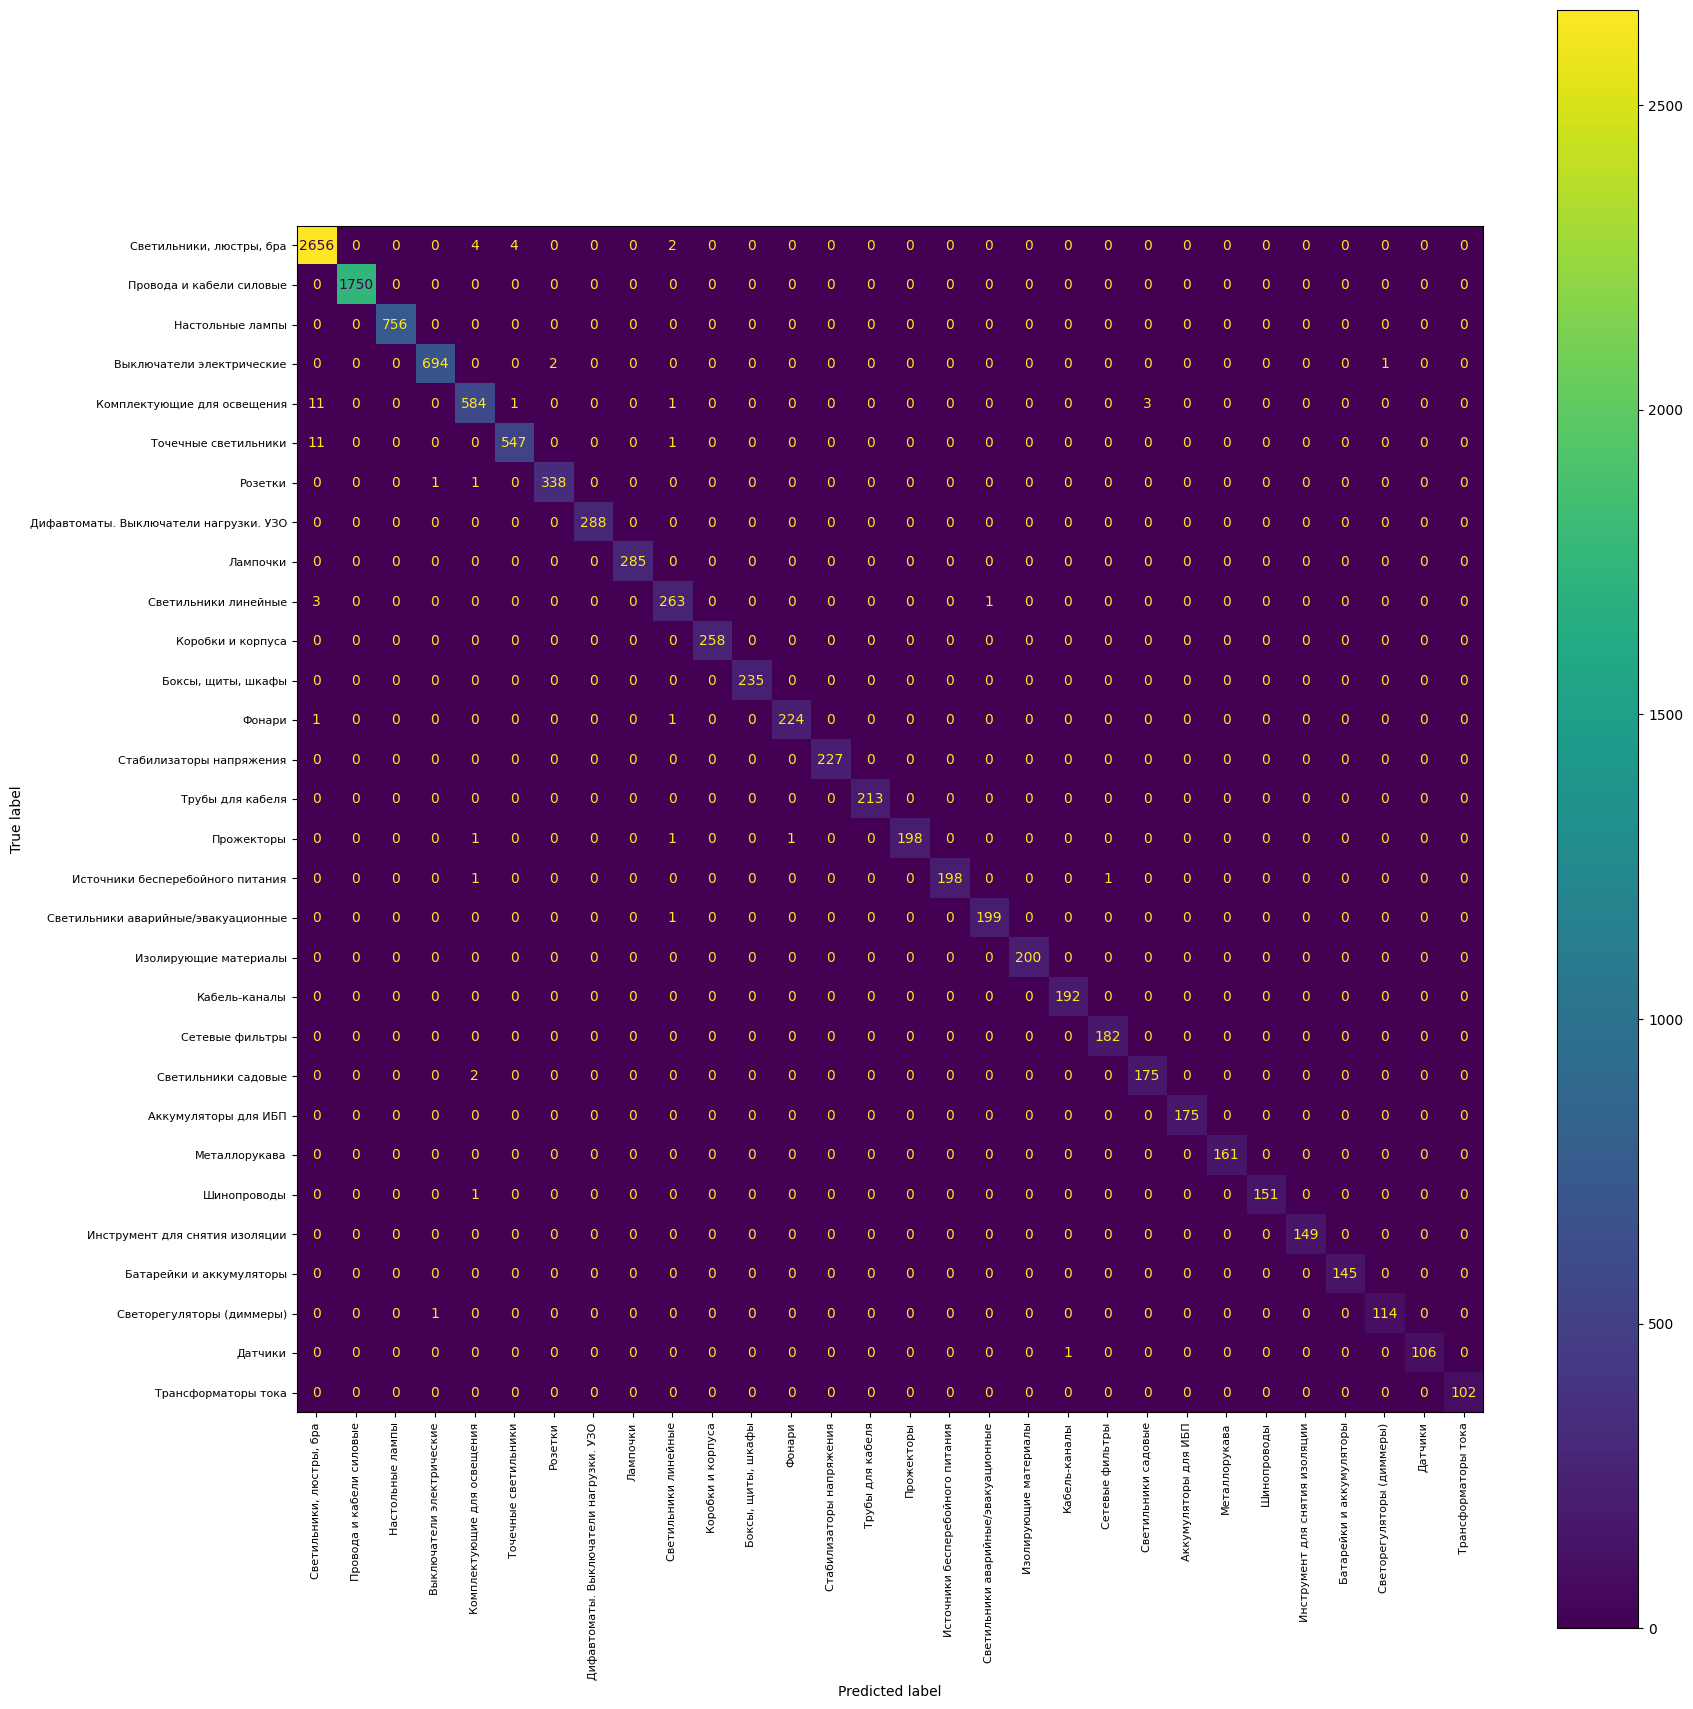

In [20]:
def plot_confusion_topn(
    y_true_ids: np.ndarray,
    y_pred_ids: np.ndarray,
    id2label: Dict[int, str],
    topn: int = 30,
    out_path: str = None,
):

    y_true_lbl = np.array([id2label[int(i)] for i in y_true_ids])
    vc = pd.Series(y_true_lbl).value_counts().head(topn)
    top_labels = vc.index.tolist()

    mask = pd.Series(y_true_lbl).isin(top_labels).to_numpy()
    yt = y_true_lbl[mask]
    yp = np.array([id2label[int(i)] for i in y_pred_ids])[mask]


    cm = confusion_matrix(yt, yp, labels=top_labels)

 
    size = max(14, int(topn * 0.6))   # ключевая строка
    fig, ax = plt.subplots(figsize=(size, size))

    disp = ConfusionMatrixDisplay(cm, display_labels=top_labels)
    disp.plot(
        ax=ax,
        xticks_rotation=90,
        values_format="d",
        colorbar=True,
    )


    ax.tick_params(axis="x", labelsize=8)
    ax.tick_params(axis="y", labelsize=8)
    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")

    plt.tight_layout()

    if out_path:
        plt.savefig(out_path, dpi=300, bbox_inches="tight")

    plt.show()

plot_confusion_topn(
    y_test,
    y_test_pred,
    id2label,
    topn=30,
    out_path=os.path.join(FIG_DIR, "confusion_top30_test.png"),
)



Confusion matrix построена для 30 самых частотных категорий на тестовой выборке и отражает реальные ошибки модели в наиболее значимых классах. Почти все значения сосредоточены на главной диагонали, что означает корректную классификацию подавляющего большинства объектов и напрямую подтверждает высокие значения accuracy и weighted-F1. Отсутствие выраженных полос вне диагонали указывает на то, что модель не имеет систематического смещения и не путает массово одну категорию с другой.

Ошибки вне диагонали единичны и малочисленны по сравнению с числом правильных предсказаний. Они возникают преимущественно между семантически близкими категориями, например внутри одной товарной группы (разные типы светильников, элементы кабельной инфраструктуры, комплектующие). Такой характер ошибок является ожидаемым для текстовой классификации, где наименования товаров часто пересекаются по лексике и назначению.

Важно, что ошибки локализованы и не образуют каскадных или асимметричных искажений, то есть модель не "залипает" на одной категории и не вытесняет другие, что указывает на хорошую разделимость признакового пространства и корректную настройку регуляризации. В практическом смысле матрица подтверждает, что оставшиеся ошибки носят пограничный характер и могут быть дополнительно снижены точечной доработкой данных или иерархической классификацией, без необходимости пересмотра всей модели.

Сохранение артефактов

In [21]:
def save_artifacts(
    model: Pipeline,
    label2id: Dict[str, int],
    id2label: Dict[int, str],
    metrics: dict,
    seen_titles: set[str] | None = None,
    out_dir: str = "models",
) -> None:
    """Save model, labels, metrics, and seen_titles for inference."""
    os.makedirs(out_dir, exist_ok=True)
    joblib.dump(model, os.path.join(out_dir, "model.joblib"))

    labels_data = {"label2id": label2id, "id2label": {str(k): v for k, v in id2label.items()}}
    if seen_titles is not None:
        labels_data["seen_titles"] = list(seen_titles)  # JSON doesn't support sets
    
    with open(os.path.join(out_dir, "labels.json"), "w", encoding="utf-8") as f:
        json.dump(labels_data, f, ensure_ascii=False, indent=2)

    with open(os.path.join(out_dir, "metrics.json"), "w", encoding="utf-8") as f:
        json.dump(metrics, f, ensure_ascii=False, indent=2)


def load_artifacts(out_dir: str = "models") -> tuple[Pipeline, Dict[int, str], dict, set[str] | None]:
    """Load model, labels, metrics, and seen_titles."""
    model = joblib.load(os.path.join(out_dir, "model.joblib"))
    labels = json.load(open(os.path.join(out_dir, "labels.json"), "r", encoding="utf-8"))
    id2label = {int(k): v for k, v in labels["id2label"].items()}

    metrics = {}
    mpath = os.path.join(out_dir, "metrics.json")
    if os.path.exists(mpath):
        metrics = json.load(open(mpath, "r", encoding="utf-8"))
    
    seen_titles = None
    if "seen_titles" in labels:
        seen_titles = set(labels["seen_titles"])
    
    return model, id2label, metrics, seen_titles



In [28]:
def predict_strict(
    titles: List[str],
    model: Any,
    id2label: Dict[int, str],
    *,
    margin_threshold: float = 0.25,
    seen_titles: set[str] | None = None,
) -> List[dict]:
    """Predict with margin check.
    
    Args:
        seen_titles: Optional set of known titles. If provided and title is not in set,
                    adds warning to message but still attempts prediction.
                    Model should classify new titles based on features, not exact match.
    """

    results = []
    for t in titles:
        t_norm = normalize_text(t)
        
        # Optional: check if title was seen (for logging/debugging, not blocking)
        is_seen = seen_titles is not None and title_key(t_norm) in seen_titles

        scores2d, classes = decision_scores_and_classes(model, [t_norm])
        scores = scores2d[0]

        best_pos = int(np.argmax(scores))
        best_class = int(classes[best_pos])

        if scores.size > 1:
            second_best = float(np.partition(scores, -2)[-2])
        else:
            second_best = float("-inf")

        best_score = float(scores[best_pos])
        margin = best_score - second_best

        if margin < margin_threshold:
            msg = f"Low confidence: margin={margin:.3f} < {margin_threshold}"
            if seen_titles is not None and not is_seen:
                msg += " (title not in training set)"
            results.append({
                "title": t,
                "status": "OUT_OF_CATEGORY_LIST",
                "category": None,
                "message": msg,
            })
            continue

        msg = f"margin={margin:.3f}"
        if seen_titles is not None and not is_seen:
            msg += " (new title, classified by features)"
        
        results.append({
            "title": t,
            "status": "OK",
            "category": id2label[best_class],
            "message": msg,
        })

    return results



In [29]:
def predict_smart(
    titles: List[str],
    model: Any,
    id2label: Dict[int, str],
    *,
    margin_threshold: float = 0.25,
    proba_threshold: float = 0.55,
    seen_titles: set[str] | None = None,
) -> List[dict]:

    results: List[dict] = []

    for t in titles:
        t_norm = normalize_text(t)
        
        # Optional: check if title was seen (for logging/debugging, not blocking)
        is_seen = seen_titles is not None and title_key(t_norm) in seen_titles

        clf = _get_clf(model)

        if hasattr(model, "predict_proba"):
            proba = np.asarray(model.predict_proba([t_norm]))[0]
            classes = np.asarray(getattr(clf, "classes_", np.arange(proba.shape[0])))

            best_pos = int(np.argmax(proba))
            best_class = int(classes[best_pos])
            conf = float(proba[best_pos])

            if conf < proba_threshold:
                msg = f"Low confidence (proba={conf:.3f} < {proba_threshold:.2f}). Not assigned."
                if seen_titles is not None and not is_seen:
                    msg += " (title not in training set)"
                results.append({
                    "title": t,
                    "status": "OUT_OF_CATEGORY_LIST",
                    "category": None,
                    "message": msg,
                })
                continue

            msg = f"proba={conf:.3f}"
            if seen_titles is not None and not is_seen:
                msg += " (new title, classified by features)"
            results.append({
                "title": t,
                "status": "OK",
                "category": id2label[best_class],
                "message": msg,
            })
            continue

        scores2d, classes = decision_scores_and_classes(model, [t_norm])
        scores = scores2d[0]

        best_pos = int(np.argmax(scores))
        best_class = int(classes[best_pos])

        best_score = float(scores[best_pos])
        second_score = float(np.partition(scores, -2)[-2]) if scores.size > 1 else float("-inf")
        margin = best_score - second_score

        if margin < margin_threshold:
            msg = f"Low confidence (margin={margin:.3f} < {margin_threshold:.2f}). Not assigned."
            if seen_titles is not None and not is_seen:
                msg += " (title not in training set)"
            results.append({
                "title": t,
                "status": "OUT_OF_CATEGORY_LIST",
                "category": None,
                "message": msg,
            })
            continue

        msg = f"margin={margin:.3f}"
        if seen_titles is not None and not is_seen:
            msg += " (new title, classified by features)"
        results.append({
            "title": t,
            "status": "OK",
            "category": id2label[best_class],
            "message": msg,
        })

    return results


seen_titles = set(df["title"].map(title_key).tolist())



In [30]:
metrics_summary = {
    "seed": SEED,
    "split": {"test_size": TEST_SIZE, "val_size": VAL_SIZE},
    "baseline": {"val": val_metrics, "test": test_metrics, "config": asdict(baseline_cfg)},
    "final": {
        "val": final_val,
        "test": final_test,
        "config": asdict(final_cfg),
        "best_C": float(best_C),
        "best_C_metrics": {k: float(v) if isinstance(v, (np.integer, np.floating)) else v for k, v in best_row.to_dict().items()},
    },
    "rows": {"train": int(len(train_df)), "val": int(len(val_df)), "test": int(len(test_df))},
    "categories": int(df["category"].nunique()),
}

# Сохраняем модель, labels, метрики и seen_titles через функцию
save_artifacts(
    final_model,
    label2id,
    id2label,
    metrics_summary,
    seen_titles=seen_titles,
    out_dir=OUT_DIR,
)

print("Saved artifacts to:", OUT_DIR)


Saved artifacts to: models


Проверка:

In [31]:
titles_path = r".\data\import.csv"

with open(titles_path, "r", encoding="cp1251", errors="ignore") as f:
    sample_titles = [line.strip() for line in f if line.strip()]
    sample_titles = sample_titles[1:]

print(f"Загружено наименований товаров: {len(sample_titles)}")


model_loaded, id2label_loaded, metrics_loaded, seen_titles_loaded = load_artifacts(OUT_DIR)

if seen_titles_loaded is None:
    print("[WARN] seen_titles not found in artifacts, using local variable if available")
    # Fallback to local variable if it exists (for backward compatibility)
    try:
        seen_titles_loaded = seen_titles
    except NameError:
        print("[ERROR] seen_titles not available. Model may not reject unseen titles correctly.")
        seen_titles_loaded = None

preds = predict_strict(sample_titles, model_loaded, id2label_loaded, seen_titles=seen_titles_loaded)
preds = predict_smart(sample_titles, model_loaded, id2label_loaded, margin_threshold=0.25, proba_threshold=0.55, seen_titles=seen_titles_loaded)

pred_df = pd.DataFrame(preds)

result = pd.DataFrame({"title": sample_titles})
result["pred_status"] = pred_df["status"]
result["pred_category"] = pred_df["category"]
result["pred_message"] = pred_df["message"]

out_path = r".\data\categorized.csv"
result.to_csv(out_path, index=False, encoding="utf-8-sig")

print(f"Товары распределены по категориям: {out_path}")

Загружено наименований товаров: 26


MemoryError: 